# Teoria de Jogos Evolutivos – O Dilema do Prisioneiro

Vinicius Trindade Dias Abel - 2020007112

## Implementação

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numba
from numba import jit
import random

In [2]:
@jit(nopython=True)
def vizinhos(N):
    """
    Calcula a tabela de vizinhos para uma grade 2D com condições de contorno periódicas.
    """
    L = int(np.sqrt(N))  # Calcula o tamanho de cada lado da rede, assumindo que é quadrada.
    viz = np.zeros((N, 4), dtype=np.int32)  # Inicializa a tabela de vizinhos (N nós, 4 vizinhos por nó).

    for k in range(N):  # Itera sobre cada nó da rede.
        # Vizinho à direita
        viz[k, 0] = k + 1
        if (k + 1) % L == 0:  # Se ultrapassou o limite direito, volta ao início da linha.
            viz[k, 0] = k + 1 - L

        # Vizinho abaixo
        viz[k, 1] = k + L
        if k >= (N - L):  # Se ultrapassou o limite inferior, conecta à linha superior.
            viz[k, 1] = k + L - N

        # Vizinho à esquerda
        viz[k, 2] = k - 1
        if k % L == 0:  # Se ultrapassou o limite esquerdo, conecta ao lado direito.
            viz[k, 2] = k + L - 1

        # Vizinho acima
        viz[k, 3] = k - L
        if k < L:  # Se ultrapassou o limite superior, conecta à linha inferior.
            viz[k, 3] = k + N - L

    return viz  # Retorna a tabela de vizinhos.

In [3]:
@jit(nopython=True)
def simula_dilema(L, b, K, max_iter):
    """
    Simula o dilema do prisioneiro em uma rede quadrada.
    """

    # Define constantes para identificação de cooperadores e desertores
    cooperador = 0
    desertor = 1

    N = L * L # Número total de nós na rede.
    viz = vizinhos(N) # Calcula os vizinhos de cada nó na rede.

    # Define a matriz de ganhos, onde matriz_ganhos[i][j] representa o ganho para individuo i interagindo com vizinho j.
    matriz_ganhos = np.array([[1.0, 0.0], [b, 0.0]])

    # Inicializa a rede aleatoriamente com 0 (cooperador) ou 1 (desertor).
    rede = np.zeros(shape=N, dtype=np.int8)
    for i in range(N):
        rede[i] = random.randint(0, 1)

    # Calcula a densidade inicial de cooperadores.
    densidade_cooperadores =  1 - np.count_nonzero(rede) / N

    # Lista para armazenar a densidade de cooperadores ao longo do tempo.
    densidades = np.zeros(shape=max_iter, dtype=np.float64)
    densidades[0] = densidade_cooperadores

    # Simulação de Monte Carlo.
    for i in np.arange(max_iter):

        # Seleciona um indivíduo aleatório na rede.
        individuo_aleatorio = random.randint(0, N)

        # Calcula o ganho do indivíduo aleatório.
        estrategia = rede[individuo_aleatorio]
        estrategia_vizinhos = np.append(rede[viz[individuo_aleatorio]], estrategia)
        ganho_individuo = np.sum(matriz_ganhos[estrategia][estrategia_vizinhos])

        # Seleciona um vizinho aleatório do indivíduo.
        vizinho_aleatorio = viz[individuo_aleatorio][random.randint(0, 4)]

        # Calcula o ganho do vizinho selecionado.
        estrategia = rede[vizinho_aleatorio]
        estrategia_vizinhos = np.append(rede[viz[vizinho_aleatorio]], estrategia)
        ganho_vizinho = np.sum(matriz_ganhos[estrategia][estrategia_vizinhos])

        # Calcula a diferença de ganhos entre o vizinho e o indivíduo.
        delta_E = ganho_vizinho - ganho_individuo

        # Calcula a probabilidade de transição baseada no fator de irracionalidade K.
        W = 1 / (1 + np.exp(- delta_E / K))

        # Decide se o indivíduo muda de estratégia para a do vizinho.
        if random.random() < W:
            if rede[individuo_aleatorio] != rede[vizinho_aleatorio]:
                # Atualiza a densidade de cooperadores caso haja mudança de estratégia.
                if rede[individuo_aleatorio] == cooperador:
                    densidade_cooperadores -= 1 / N
                else:
                    densidade_cooperadores += 1 / N
            rede[individuo_aleatorio] = rede[vizinho_aleatorio]

        # Atualiza a densidade no tempo atual.
        densidades[i] = densidade_cooperadores

    # Retorna a densidade ao longo do tempo e a configuração final da rede.
    return densidades, rede.reshape((L, L))

In [4]:
def plotar_densidades_por_b(densidades_por_b, variacao_b):
    """
    Plota a densidade final de cooperadores em função de b.
    """
    plt.title(f"Variação da densidade de cooperadores após convergência")
    plt.xlabel("Valor de b")
    plt.xticks(ticks=np.arange(1, 2.1, 0.10))
    plt.ylabel("Densidade de cooperadores")
    plt.plot(np.arange(1, 2 + variacao_b, variacao_b), densidades_por_b)
    plt.show()

In [5]:
@jit(nopython=True, parallel=True)
def calcula_densidade_por_b(L, array_b, K, max_iter=1000, seed=None):
    """
    Calcula a densidade de cooperadores para diferentes valores de b.
    """
    if seed is not None:
        np.random.seed(seed)

    densidades_por_b = np.zeros(shape=array_b.size, dtype=np.float64) # Inicializa array para armazenar densidades.

    # Loop paralelo para calcular densidades para cada valor de b.
    for i in numba.prange(array_b.size):
        densidades, _ = simula_dilema(L, array_b[i], K, max_iter) # Executa a simulação para cada b.
        densidades_por_b[i] = densidades[-1] # Armazena a densidade final para o valor atual de b.
    return densidades_por_b

In [6]:
def plotar_densidades_por_tempo(evolucao_densidades, b_values, max_iter):
    """
    Plota a evolução da densidade de cooperadores ao longo do tempo.
    """
    plt.figure(figsize=(12, 8))
    for i, b in enumerate(b_values):

        plt.plot(
            np.arange(max_iter),
            evolucao_densidades[i, :],
            label=f"b={b:.2f}",
            alpha=0.7
        )

    plt.title("Evolução da densidade de cooperadores para diferentes valores de b")
    plt.xlabel("Iterações")
    plt.ylabel("Densidade de cooperadores")
    plt.legend(loc='best', fontsize=8, ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

In [7]:
@jit(nopython=True, parallel=True)
def calcula_densidade_por_tempo(L, array_b, K, max_iter=1000, seed=None):
    """
    Calcula a evolução da densidade de cooperadores ao longo do tempo.
    """
    if seed is not None:
        np.random.seed(seed)

    evolucao_densidades = np.zeros((array_b.size, max_iter), dtype=np.float64) # Matriz para armazenar evoluções.

    # Loop paralelo para calcular a evolução para cada b
    for i in numba.prange(array_b.size):
        densidades, _ = simula_dilema(L, array_b[i], K, max_iter) # Simula para o valor atual de b
        evolucao_densidades[i, :] = densidades # Armazena a evolução temporal para b

    return evolucao_densidades

In [8]:
def plotar_rede(L, b, K, max_iter, seed=None):
    """
    Plota a configuração final da rede.
    """
    if seed is not None:
        np.random.seed(seed)

    _, rede = simula_dilema(L, b, K, max_iter)

    cmap = ListedColormap(["blue", "red"])
    plt.figure(figsize=(6, 6))
    plt.imshow(rede, cmap=cmap, interpolation="none", vmin=0, vmax=1)
    plt.title(f"Configuração final da rede para b={b}")
    plt.xticks([])
    plt.yticks([])
    plt.grid(color="black", linewidth=0.5)
    plt.show()

## Simulação

### K = 0.26

### Parâmetros

In [9]:
# Parâmetros
K = 0.26  # Fator de irracionalidade
L = 200  # Tamanho da rede
variacao_b = 0.01  # Variância de b
b_values = np.arange(1, 2 + variacao_b, variacao_b)  # Valores de b entre 1 e 2
max_iter = 10000000  # Iterações de Monte Carlo
seed = 33  # Semente para reprodutibilidade

### Variação de densidade por b

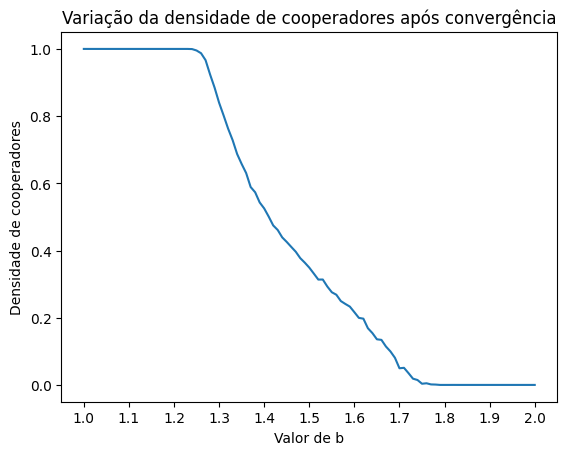

In [11]:
# Calcula densidades de cooperadores por b
densidades_por_b = calcula_densidade_por_b(L, b_values, K, max_iter, seed)

# Plotar densidade final em função de b
plotar_densidades_por_b(densidades_por_b, variacao_b)

### Evolução de densidade para cada b

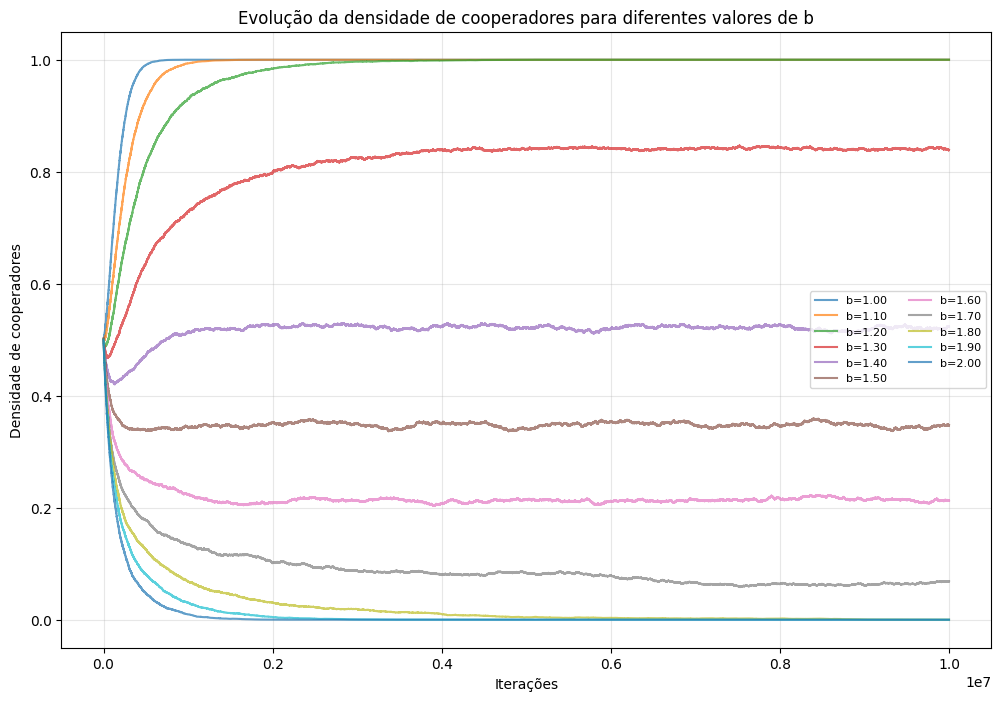

In [11]:
# Valores de b para os quais queremos visualizar a  evolução da densidade
b_values_plot = np.linspace(1.0, 2.0, 11)

# Calcula evolução da densidade de cooperadores para cada b
evolucao_densidades = calcula_densidade_por_tempo(L, b_values_plot, K, max_iter, seed)

# Plotar evolução das densidades ao longo do tempo para cada b
plotar_densidades_por_tempo(evolucao_densidades, b_values_plot, max_iter)

### Visualização das redes finais

#### b = 1

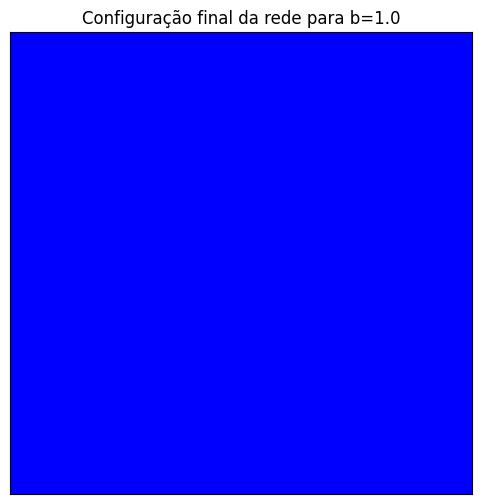

In [11]:
b = 1.0
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.1

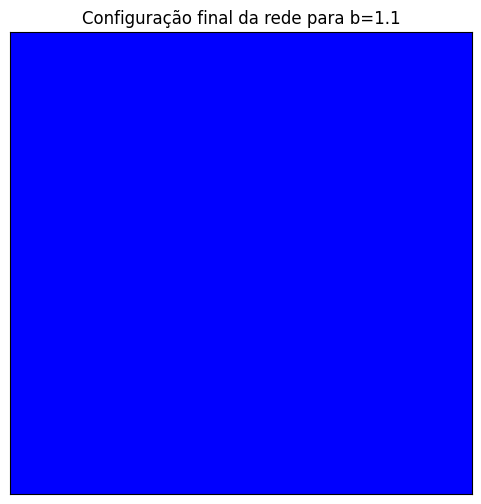

In [11]:
b = 1.1
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.2

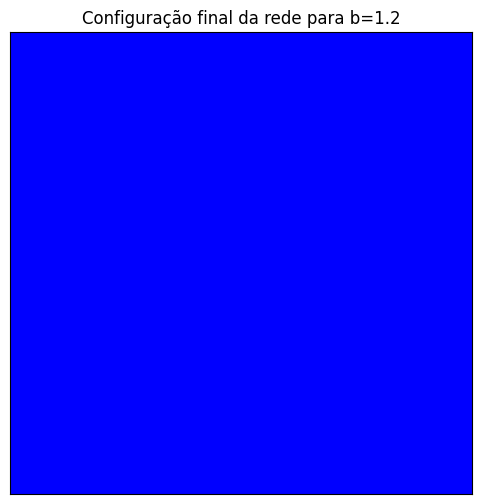

In [12]:
b = 1.2
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.3

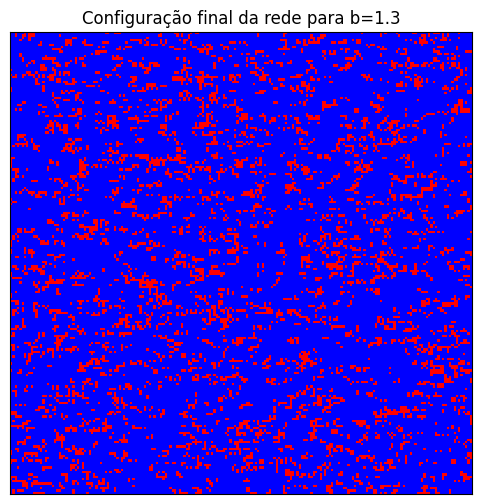

In [11]:
b = 1.3
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.4

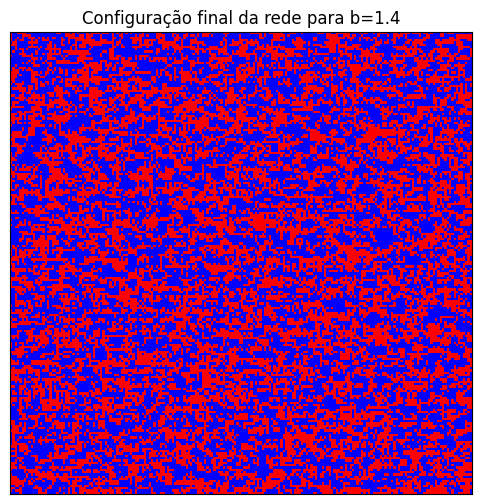

In [12]:
b = 1.4
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.5

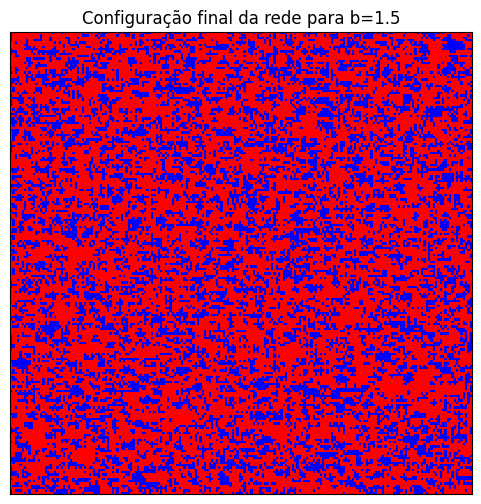

In [11]:
b = 1.5
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.6

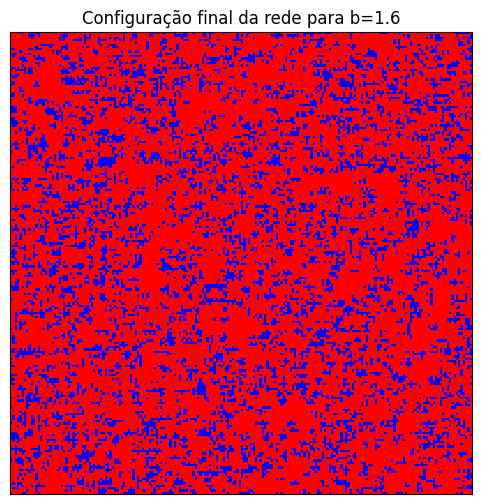

In [11]:
b = 1.6
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.7

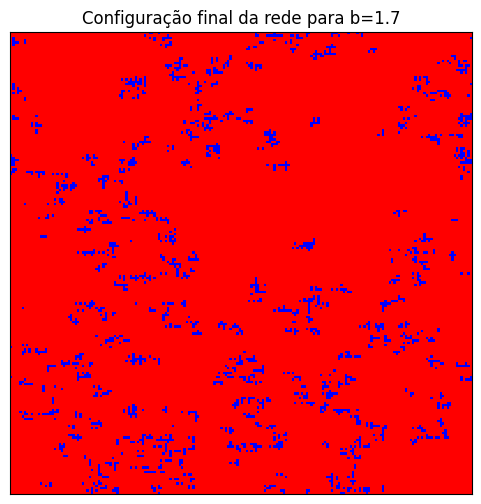

In [12]:
b = 1.7
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.8

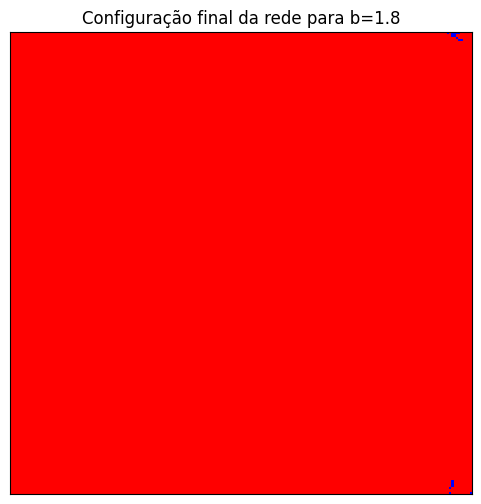

In [12]:
b = 1.8
plotar_rede(L, b, K, max_iter, seed)

#### b = 1.9

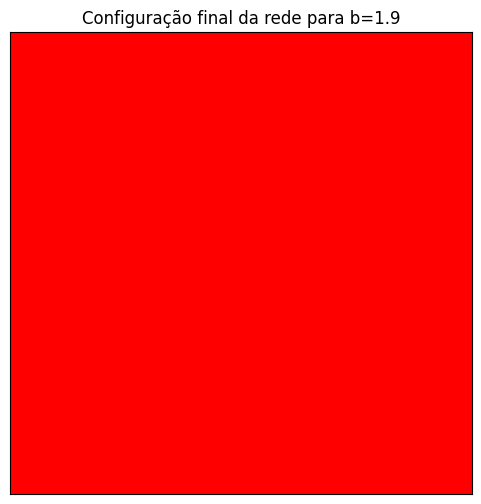

In [10]:
b = 1.9
plotar_rede(L, b, K, max_iter, seed)

#### b = 2

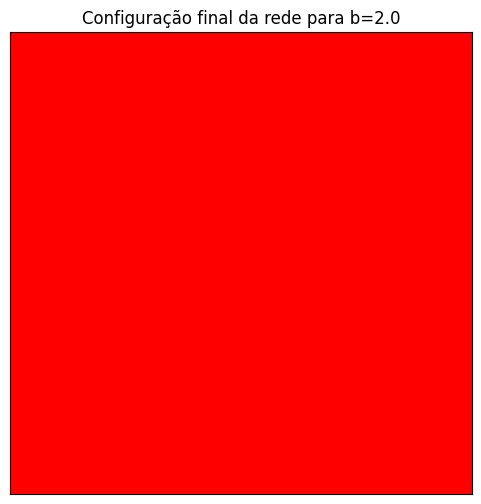

In [10]:
b = 2.0
plotar_rede(L, b, K, max_iter, seed)

## Análise de Resultados

K = 26 foi escolhido por ser um valor intermediário entre 0,02 e 0,5.

A partir dos gráficos gerados e das configurações finais da rede para  K = 0.26 , foi possível observar os seguintes comportamentos:

1. **Gráfico de variação de densidades por b**
   - Para  b <= 1.2 , a densidade de cooperadores ( c ) é aproximadamente igual a 1. Isso indica que o sistema entra em uma fase absorvente onde todos os indivíduos são cooperadores.
   - Para  b >= 1.8 , a densidade de cooperadores ( c ) é aproximadamente igual a 0. Nessa região, o sistema entra em outra fase absorvente, desta vez com todos os indivíduos desertores.
   - Para  1.2 < b < 1.8 , a densidade de cooperadores ( c ) assume valores intermediários entre 0 e 1, indicando a existência de um estado estacionário onde cooperadores e desertores coexistem.

2. **Gráfico da evolução de densidade para cada b**
   - A simulação conta com 10.000.000 de iterações para cada valor de b.
   - Com 2.000.000 de iterações o sistema ja se aproxima dos estados finais.
   - Com aproximadamente 6.000.000 de iteções o sistema chega nos estados finais, sejam fases absorventes ou estados estacionários.
   - É possível observar claramente a evolução das densidades de cooperadores ( c ) até atingirem os estados mostrados no gráfico anterior.

3. **Configuração Final da Rede**
   - Redes completamente azuis ( c = 1 ) foram observadas para  b < 1.2 , confirmando a dominância dos cooperadores.
   - Redes completamente vermelhas ( c = 0 ) foram observadas para  b > 1.8 , indicando a dominância dos desertores.
   - Configurações mistas de cooperadores e desertores foram observadas para  1.2 < b < 1.8.
   - É possível visualizar e entender melhor os resultados apresentados nos gráficos com a plotagem das redes.

---

Como dito anteriormente, os resultados indicam que:
- **b_1 = 1.2** - Este é o limite inferior, abaixo do qual todos os indivíduos são cooperadores.
- **b_2 = 1.8** - Este é o limite superior, acima do qual todos os indivíduos são desertores.

---

##### Conclusão

Para K = 0.26, os resultados indicam claramente a existência de três regiões distintas no sistema:

1. **Região de Predominância de Cooperadores  b < b_1):**
   - O sistema converge para um estado onde todos os indivíduos são cooperadores.
   - Este comportamento é indicado pelos valores c = 1 e pelas redes completamente azuis.

2. **Região Estacionária  b_1 < b < b_2):**
   - O sistema atinge um estado estacionário com coexistência de cooperadores e desertores.
   - A densidade c assume valores intermediários e apresenta oscilações antes de estabilizar.
   - É indicado pelas redes de cores mistas.

3. **Região de Predominância de Desertores  b > b_2):**
   - O sistema converge para um estado onde todos os indivíduos são desertores.
   - Este comportamento é indicado pelos valores c = 0 e pelas redes completamente vermelhas.

Esses resultados estão de acordo com o modelo descrito na tarefa, demonstrando as transições entre as fases absorventes e o estado estacionário. As estimativas de b_1 = 1.2 e b_2 = 1.8 são consistentes com os gráficos gerados.


---